In [2]:
import numpy as np                                                                        
import matplotlib.pyplot as plt
import pyCloudy as pc
import pyneb as pn
from astropy    import constants as const
from astropy.io import ascii
import pandas as pd
from scipy import interpolate
import warnings
from scipy.integrate import quad, IntegrationWarning
import scipy.integrate as integrate
from numpy import log10, exp
from astropy.constants import m_e, e ,c 
from astropy import units as u
from scipy.constants import physical_constants
from scipy.constants import physical_constants, c as cc

In [13]:
C_IV_K = 1548.187e-8  # cm
C_IV_H = 1550.772e-8  # cm

C_IV_K_A = 1548.187  # cm
C_IV_H_A = 1550.772  # cm

cc = c.to(u.cm / u.s).value  # cm/s
cc_k = c.to(u.km / u.s).value #km / s
v_th_CIV = 11.7673179819719e5  # cm/s

K_gamma = 2.65e+8
H_gamma = 2.64e+8
f_CIV_K = 0.190
f_CIV_H = 0.0952



voigt_path = r'/home/jin/Addition_RT/RT_main/CIV_Voigt_data/CIV_Voigt_30.txt'
# voigt_path = r'/home/jin/RT/RT_main/CIV_Voigt_data/Mg_II.txt'
name = ['lambda','sigma']
voigt_file = pd.read_csv(voigt_path,sep='\s+',names=name,)

lam, scat = voigt_file['lambda'].to_numpy() , voigt_file['sigma'].to_numpy()

Mg_II_K = 2795.528e-8 
Mg_II_H = 2802.705e-8

del_V =  ((lam-C_IV_K) / C_IV_K) * cc /1e5
# 
# del_V =  ((lam-Mg_II_K) / Mg_II_K) * cc /1e5

4.191559e-15 cm^2
2.095779e-15 cm^2
2.386e+14 cm^-2
(array([    0,     1,     2, ..., 99997, 99998, 99999]),)
조건을 만족하는 범위에서의 최대값: 4.1836569999999997e-19
최대값의 인덱스: 62654
7.777025348542762


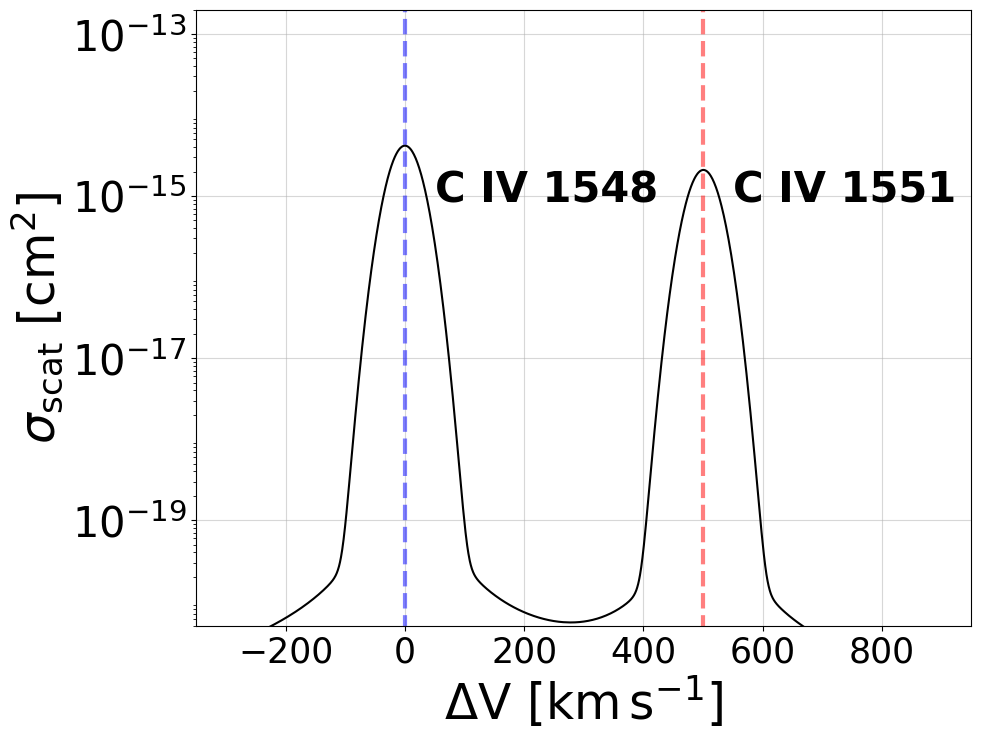

In [19]:
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, LogLocator

# 데이터와 상수는 사용자가 따로 정의했다고 가정
# del_V, scat, C_IV_H_A, C_IV_K_A, cc_k

fig = plt.figure(1, figsize=(10, 8))
ax = plt.gca()

# 그래프 그리기
plt.plot(del_V, scat, 'k-')

# 로그 스케일 설정
plt.yscale('log')
plt.xlim(-350, 950)
plt.ylim(0.5e-20, 2e-13)

# 수직선 그리기
HH = (C_IV_H_A / C_IV_K_A - 1) * cc_k
plt.axvline(0, ymin=-1, ymax=1, linestyle='--', color='b', alpha=0.5, lw=3)
plt.axvline(HH, ymin=-1, ymax=1, linestyle='--', color='r', alpha=0.5, lw=3)

# 라벨 및 눈금 설정
plt.ylabel(r'$\sigma_{\rm scat} ~ [\rm cm^{2}]$', fontsize=35)
plt.xlabel(r'$\Delta \rm V ~ [\rm km \, s^{-1}]$', fontsize=35)

print(f'{scat.max():.6e} cm^2')
print(f'{scat.max()/2:.6e} cm^2')
print(f'{1/scat.max():.3e} cm^-2')


hh = np.where(del_V>=500)[0]
kk = np.where(del_V<500)[0]

pp_k = np.argmax(scat[kk])
pp_h = np.argmax(scat[hh])

pp_h = pp_h + hh[0]
# print(pp_h)

plt.text(del_V[pp_k]+50,scat[pp_k]/5,'C IV 1548',fontweight='bold',fontsize=30)

plt.text(del_V[pp_h]+50,scat[pp_k]/5,'C IV 1551',fontweight='bold',fontsize=30)

plt.yticks([10e-20, 10e-18, 10e-16, 10e-14], fontsize=30)
plt.xticks(fontsize=25)

print(np.where(scat*1e-4<=scat.max()))
mask = scat<= scat.max()*1e-4 
if np.any(mask):
    max_in_range = scat[mask].max()
    max_index = np.where(scat == max_in_range)[0][0]
    
    print(f"조건을 만족하는 범위에서의 최대값: {max_in_range}")
    print(f"최대값의 인덱스: {max_index}")
    print(del_V[max_index]*1e5/v_th_CIV)
    # plt.axvline(x=del_V[max_index],ymin=0,ymax=1,linestyle='--')

# # 보조 눈금 설정
# ax.xaxis.set_minor_locator(AutoMinorLocator())
# ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=[2, 3, 5, 7, 9], numticks=100))

# # 눈금 방향 설정
# ax.tick_params(which='minor', direction='in', length=5)
# ax.tick_params(which='major', direction='in', length=10)

# 그리드 설정
plt.grid(True, linestyle='-', alpha=0.5)

# 저장 (필요 시 주석 해제)
# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/Scattering_cross_section.pdf', bbox_inches='tight')
# 

# plt.show()


4.191559e-15 cm^2
2.095779e-15 cm^2
2.386e+14 cm^-2


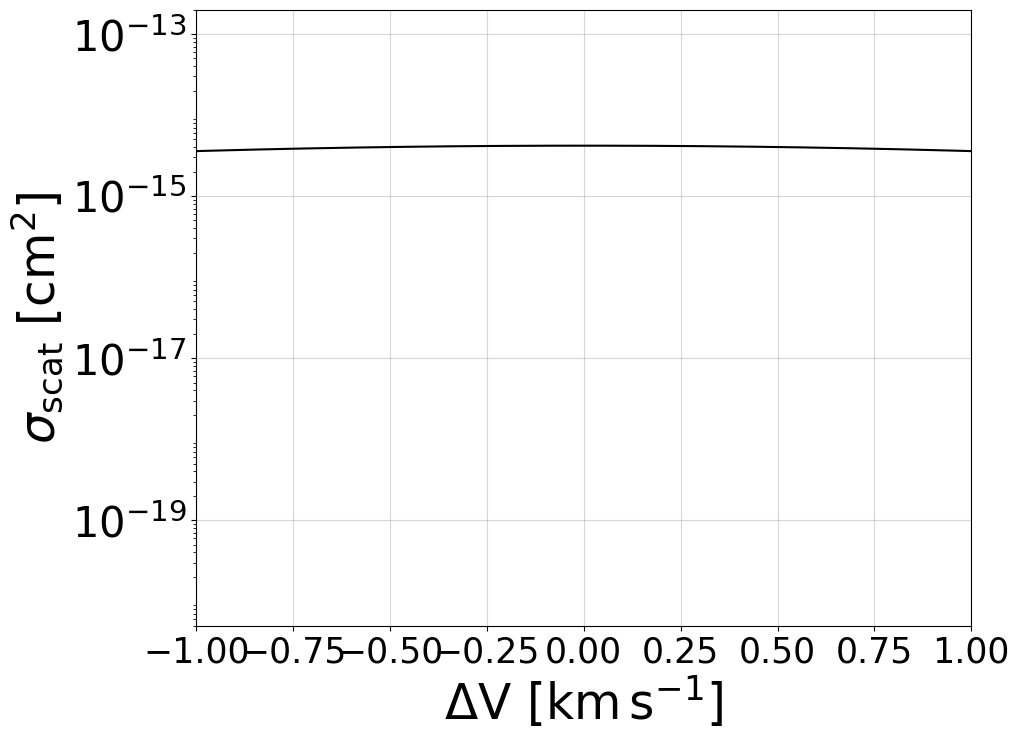

In [20]:
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, LogLocator

# 데이터와 상수는 사용자가 따로 정의했다고 가정
# del_V, scat, C_IV_H_A, C_IV_K_A, cc_k

fig = plt.figure(1, figsize=(10, 8))
ax = plt.gca()

# 그래프 그리기
plt.plot(del_V/(-11.8), scat, 'k-')

# 로그 스케일 설정
plt.yscale('log')
# plt.xlim(-350, 950)
#x_H = -42.5
plt.xlim(-1, 1)
plt.ylim(0.5e-20, 2e-13)

# 수직선 그리기
HH = (C_IV_H_A / C_IV_K_A - 1) * cc_k
# plt.axvline(0, ymin=-1, ymax=1, linestyle='--', color='b', alpha=0.5, lw=3)
# plt.axvline(HH, ymin=-1, ymax=1, linestyle='--', color='r', alpha=0.5, lw=3)

# 라벨 및 눈금 설정
plt.ylabel(r'$\sigma_{\rm scat} ~ [\rm cm^{2}]$', fontsize=35)
plt.xlabel(r'$\Delta \rm V ~ [\rm km \, s^{-1}]$', fontsize=35)

print(f'{scat.max():.6e} cm^2')
print(f'{scat.max()/2:.6e} cm^2')
print(f'{1/scat.max():.3e} cm^-2')


hh = np.where(del_V>=500)[0]
kk = np.where(del_V<500)[0]

pp_k = np.argmax(scat[kk])
pp_h = np.argmax(scat[hh])

pp_h = pp_h + hh[0]
# print(pp_h)

# plt.text(del_V[pp_k]+50,scat[pp_k]/5,'C IV 1548',fontweight='bold',fontsize=30)

# plt.text(del_V[pp_h]+50,scat[pp_k]/5,'C IV 1551',fontweight='bold',fontsize=30)

plt.yticks([10e-20, 10e-18, 10e-16, 10e-14], fontsize=30)
plt.xticks(fontsize=25)

# print(np.where(scat*1e-4<=scat.max()))
# mask = scat<= scat.max()*1e-4 
# if np.any(mask):
#     max_in_range = scat[mask].max()
#     max_index = np.where(scat == max_in_range)[0][0]
    
#     print(f"조건을 만족하는 범위에서의 최대값: {max_in_range}")
#     print(f"최대값의 인덱스: {max_index}")
#     print(del_V[max_index]*1e5/v_th_CIV)
#     # plt.axvline(x=del_V[max_index],ymin=0,ymax=1,linestyle='--')

# # # 보조 눈금 설정
# ax.xaxis.set_minor_locator(AutoMinorLocator())
# ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=[2, 3, 5, 7, 9], numticks=100))

# # 눈금 방향 설정
# ax.tick_params(which='minor', direction='in', length=5)
# ax.tick_params(which='major', direction='in', length=10)

# 그리드 설정
plt.grid(True, linestyle='-', alpha=0.5)

# 저장 (필요 시 주석 해제)
# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/Scattering_cross_section.pdf', bbox_inches='tight')
# 

# plt.show()


In [21]:
from astropy.constants import h, c, k_B
h_ev = h.to(u.eV *u.s).value

Ly_a_K = 1215.673644609e-8
Ly_a_H = 1215.668237310e-8
C_IV_K = 1548.187e-8  # cm
C_IV_H = 1550.772e-8  # cm  
c_cms=c.to(u.cm/u.s).value

nu_CIV_K = c_cms /C_IV_K
nu_CIV_H = c_cms /C_IV_H

nu_Lya_K = c_cms /Ly_a_K
nu_Lya_H = c_cms /Ly_a_H

Ryd_CIV_K=  h_ev*nu_CIV_K / 13.6
Ryd_CIV_H=  h_ev*nu_CIV_H / 13.6
print(h_ev*nu_CIV_K - h_ev*nu_CIV_H, 0.015)
print(h_ev*nu_Lya_K - h_ev*nu_Lya_H, 0.005)

print(((c_cms /(C_IV_K - 5e-8))*h_ev) - h_ev*nu_CIV_K )
print((c_cms /(C_IV_H + 5e-8))*h_ev - h_ev*nu_CIV_H)
# print(h_ev*nu_Lya_K/13.6)

0.013349208572114968 0.015
-4.5364345803378114e-05 0.005
0.025947431282082434
-0.02569463430055663


In [22]:
print(f'{1/ scat[pp_k]:.2e}')
print(f'{scat[pp_h]:.2e}')

2.39e+14
2.10e-15


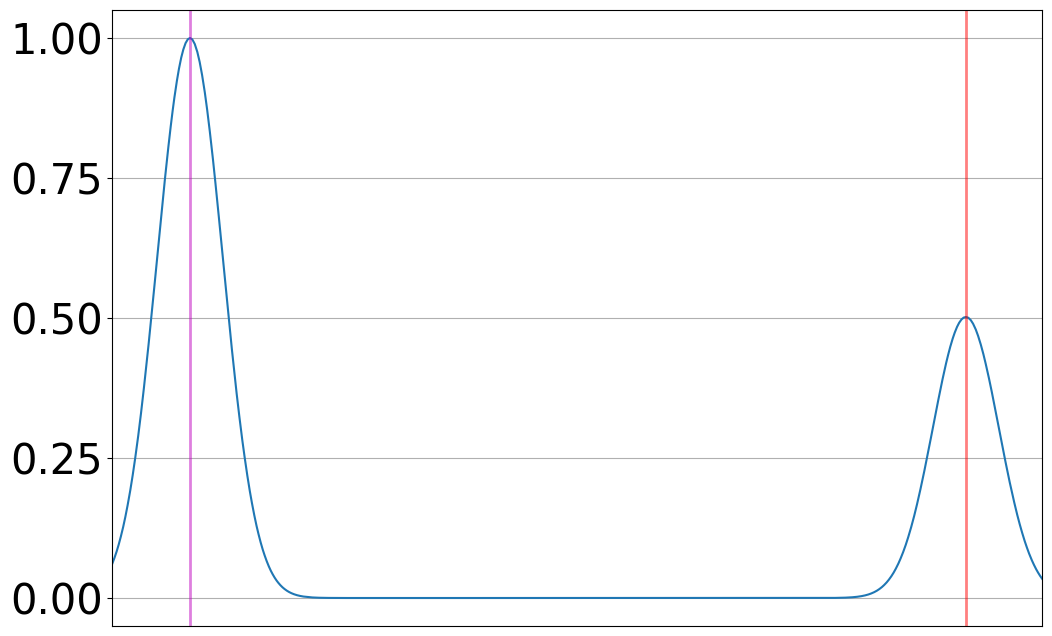

In [23]:
fig = plt.figure(1,figsize=(12,8))

plt.plot(del_V,scat / scat.max())
# plt.yscale('log')
plt.xlim(-50,550)
# plt.ylim(0.5e-20,5e-13)
HH = (C_IV_H_A/ C_IV_K_A -1 ) *cc_k
plt.axvline(0,ymin=-1,ymax=1,linestyle='-',color='m',alpha=0.5,lw=2)
plt.axvline(HH,ymin=-1,ymax=1,linestyle='-',color='r',alpha=0.5,lw=2)
# plt.ylabel(r'$\sigma_{\rm scat} ~ [\rm cm^{2}]$',fontsize=35)
# plt.xlabel(r'$\Delta \rm V ~ [\rm km \, s^{-1}]$',fontsize=35)
plt.yticks([0,0.25,0.5,0.75,1.0],fontsize=30)
plt.xticks([],fontsize=25)
# plt.savefig('/home/jin/바탕화면/Scattering cross_section.png',bbox_inches='tight')
# plt.axhline(y=1e-14,xmin=0,xmax=1,linestyle='--')
plt.grid(True)
# plt.savefig('/home/jin/바탕화면/Scattering cross_section_big.png',bbox_inches='tight')

# dx= 0.05
# ii = np.where( (del_V > 0-dx) & (del_V < 0+dx) )[0]
# jj = np.where( (del_V > 500-dx) & (del_V < 500+dx) )[0]
# print((scat[ii]) ,1/scat[ii])
# print(jj)